# OpenMC transport model for the frm2 geometry using natural uranium

Modularize so concentric_modeling.ipynb reuses python files
Optimization.py should follow a similar workflow, searching for best k_eff (closest to 1.005) then presenting a list of best candidates (because size matters and I prefer smaller cores)


 ## Models

In [1]:
import importlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import openmc

import fuel_element
import involutes
import reactor_geometry
import build_simulation
from ploting import plot_reactor_preview, resolve_openmc_exec, show_statepoint_diagnostics

importlib.reload(involutes)
importlib.reload(fuel_element)
importlib.reload(reactor_geometry)
importlib.reload(build_simulation)

from fuel_element import quick_layout_plot
from involutes import InvoluteElementParameters, build_parameter_report, validate_parameters
from reactor_geometry import ReactorTankParameters, validate_reactor_tanks

FUEL_ELEMENT_PARAMETERS = InvoluteElementParameters(
    plate_count=12,
    plate_thickness_cm=1.0,
    coolant_gap_cm=12.0,
    inner_radius_cm=25.0,
    outer_radius_cm=50.0,
    control_rod_radius_cm=4.0,
    h_active_cm=300.0,
    lower_plenum_cm=50.0,
    upper_plenum_cm=50.0,
    segments_per_plate=24,
    base_radius_cm=None,
    fuel_density_g_per_cm3=12.2,
    fuel_enrichment_wt_pct=0.7198,
 )
# k = 1.07 with: 12 plates, plate_thickness_cm=1.0, coolant_gap_cm=12.0, inner_radius_cm=25.0, outer_radius_cm=50.0, h_active_cm=300.0

REACTOR_TANK_PARAMETERS = ReactorTankParameters(
    d2o_tank_radius_cm=300,
    h2o_tank_radius_cm=500.0,
    h_d2o_tank_cm=600,
    h_h2o_tank_cm=1000.0,
 )

validate_parameters(FUEL_ELEMENT_PARAMETERS)
validate_reactor_tanks(FUEL_ELEMENT_PARAMETERS, REACTOR_TANK_PARAMETERS)

GEOMETRY = build_parameter_report(FUEL_ELEMENT_PARAMETERS)
GEOMETRY.update(REACTOR_TANK_PARAMETERS.to_geometry_dict())

GLOBAL_MESH_SHAPE = (160, 160)
FUEL_MESH_SHAPE = (220, 220)
DEFAULT_OPENMC_THREADS = os.cpu_count() or 1
OPENMC_THREADS = int(os.environ.get("OPENMC_THREADS", DEFAULT_OPENMC_THREADS))
OPENMC_EXEC = resolve_openmc_exec()

BUILD_DIR = Path("build") / "notebook"
PREVIEW_DIR = BUILD_DIR / "preview"
RUN_DIR = BUILD_DIR / "reactor_run"
for build_path in (BUILD_DIR, PREVIEW_DIR, RUN_DIR):
    build_path.mkdir(parents=True, exist_ok=True)

GEOMETRY_REPORT = {
    "fuel_element": build_parameter_report(FUEL_ELEMENT_PARAMETERS),
    "reactor_tanks": REACTOR_TANK_PARAMETERS.to_geometry_dict(),
    "openmc_threads": OPENMC_THREADS,
    "openmc_exec": OPENMC_EXEC,
}
GEOMETRY_REPORT

{'fuel_element': {'plate_count': 12,
  'plate_thickness_cm': 1.0,
  'coolant_gap_cm': 12.0,
  'inner_radius_cm': 25.0,
  'outer_radius_cm': 50.0,
  'control_rod_radius_cm': 4.0,
  'h_active_cm': 300.0,
  'lower_plenum_cm': 50.0,
  'upper_plenum_cm': 50.0,
  'segments_per_plate': 24,
  'base_radius_cm': 24.82817112233567,
  'fuel_density_g_per_cm3': 12.2,
  'fuel_enrichment_wt_pct': 0.7198,
  'h_total_cm': 400.0,
  'theta_inner': np.float64(0.11785304835283968),
  'theta_outer': np.float64(1.7480152642423428),
  'single_plate_length_cm': np.float64(57.21512534024451),
  'uranium_area_fraction': np.float64(0.1165576962242851),
  'uranium_volume_cm3': np.float64(205974.45122488023),
  'uranium_mass_kg': np.float64(2512.8883049435385)},
 'reactor_tanks': {'d2o_tank_radius_cm': 300,
  'h2o_tank_radius_cm': 500.0,
  'h_d2o_tank_cm': 600,
  'h_h2o_tank_cm': 1000.0,
  'h_total_cm': 1000.0},
 'openmc_threads': 19,
 'openmc_exec': '/home/pablo/miniconda3/envs/openmc/bin/openmc'}

{'plate_count': 12, 'plate_thickness_cm': 1.0, 'coolant_gap_cm': 12.0, 'inner_radius_cm': 25.0, 'outer_radius_cm': 50.0, 'control_rod_radius_cm': 4.0, 'h_active_cm': 300.0, 'lower_plenum_cm': 50.0, 'upper_plenum_cm': 50.0, 'segments_per_plate': 24, 'base_radius_cm': 24.82817112233567, 'fuel_density_g_per_cm3': 12.2, 'fuel_enrichment_wt_pct': 0.7198, 'h_total_cm': 400.0, 'theta_inner': np.float64(0.11785304835283968), 'theta_outer': np.float64(1.7480152642423428), 'single_plate_length_cm': np.float64(57.21512534024451), 'uranium_area_fraction': np.float64(0.1165576962242851), 'uranium_volume_cm3': np.float64(205974.45122488023), 'uranium_mass_kg': np.float64(2512.8883049435385)}


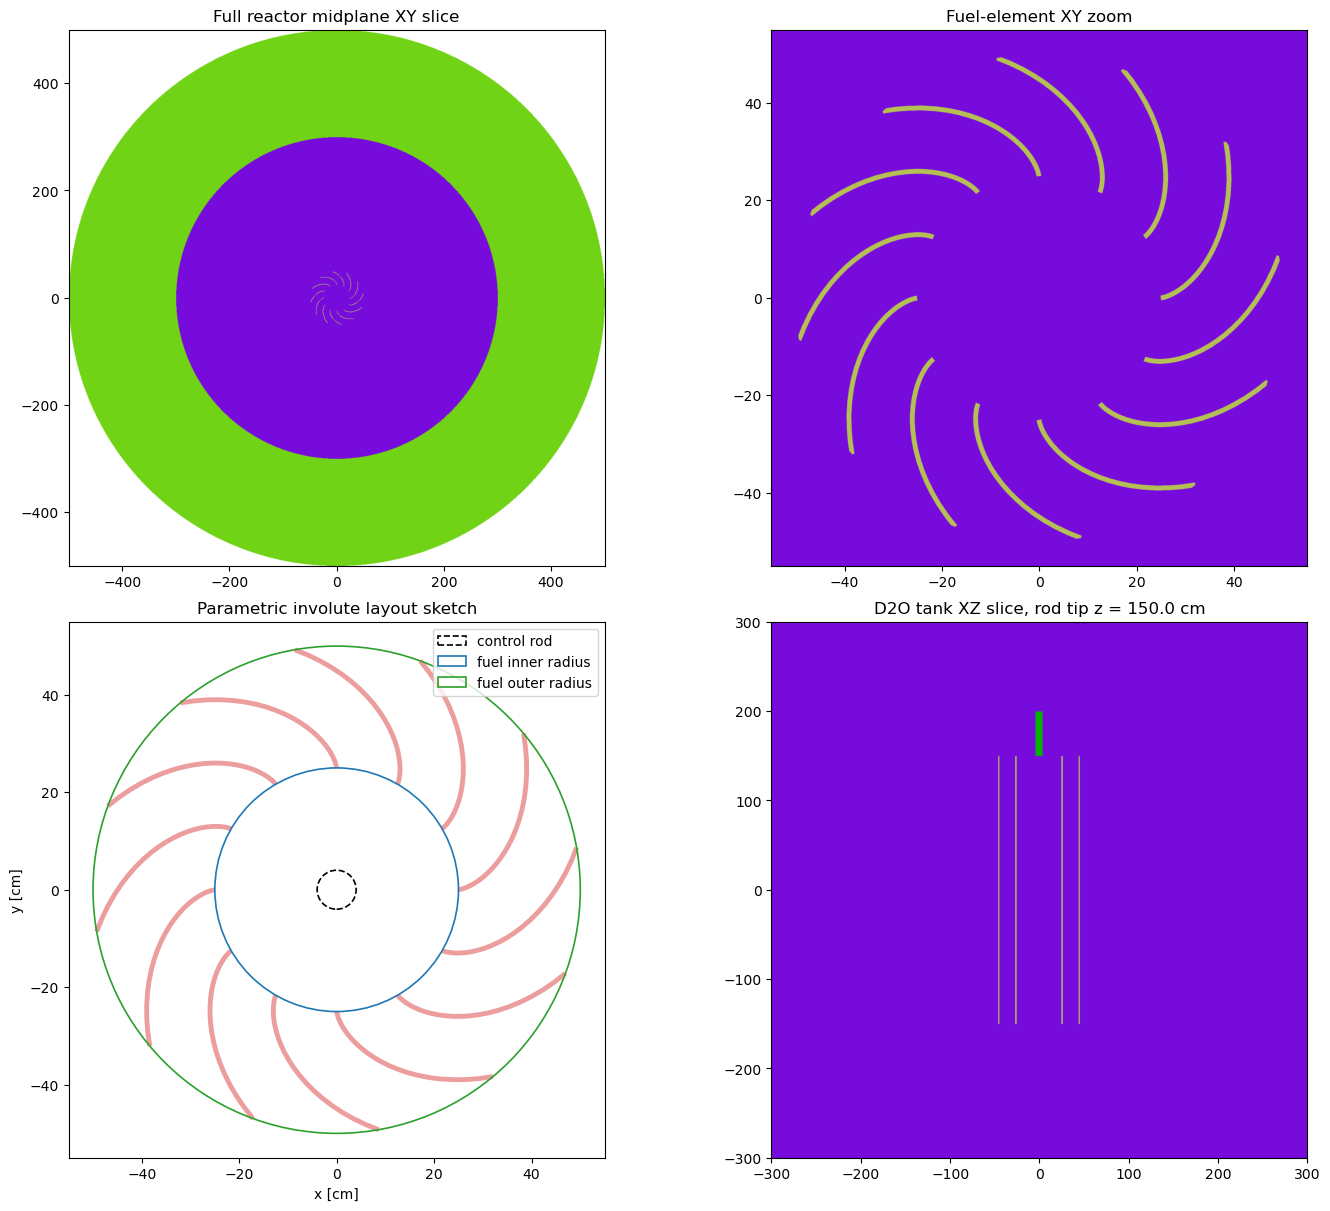

In [2]:
preview_model, preview_metadata = build_simulation.build_eigenvalue_model(
    FUEL_ELEMENT_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
    rod_insertion=0.0,
    particles=2000,
    batches=1,
    inactive=0,
    global_mesh_shape=None,
    fuel_mesh_shape=None,
)

plot_reactor_preview(
    preview_model,
    preview_metadata,
    FUEL_ELEMENT_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
    quick_layout_plot=quick_layout_plot,
    layout_title="Parametric involute layout sketch",
)
print(build_parameter_report(FUEL_ELEMENT_PARAMETERS))
plt.show()

In [3]:
cross_sections = openmc.config.get("cross_sections")

if cross_sections:
    reference_insertion = 0.0
    reference_model, reference_metadata = build_simulation.build_eigenvalue_model(
        FUEL_ELEMENT_PARAMETERS,
        REACTOR_TANK_PARAMETERS,
        rod_insertion=reference_insertion,
        particles=12000,
        batches=30,
        inactive=10,
        global_mesh_shape=GLOBAL_MESH_SHAPE,
        fuel_mesh_shape=FUEL_MESH_SHAPE,
    )
    statepoint_path = reference_model.run(
        cwd=RUN_DIR,
        threads=OPENMC_THREADS,
        openmc_exec=OPENMC_EXEC,
        export_model_xml=True,
    )
    print(f"OpenMC run finished: {statepoint_path}")
    print(f"model.xml written to {RUN_DIR / 'model.xml'}")
    if reference_metadata["tally_names"]:
        print(f"Tallies recorded: {reference_metadata['tally_names']}")
    else:
        print("No mesh tallies were attached to this run, so this is a faster k_eff-only calculation.")
else:
    statepoint_path = None
    reference_metadata = None
    print(
        "Set openmc.config['cross_sections'] or OPENMC_CROSS_SECTIONS before running eigenvalue calculations."
    )

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

# Run Diagnostics and Tallies

This cell reports the Shannon entropy history for the fission source so you can judge whether the inactive batches were sufficient before trusting the final k_eff.

The mesh plotting section still stays dormant unless the run above was executed with mesh tallies enabled by passing a non-None mesh shape to build_model.

k_eff = 1.026756 +/- 0.001682
reactivity = 2605.9 pcm
entropy mesh shape = (6, 6, 18)
final Shannon entropy = 8.868034
entropy spread over last 10 active batches = 0.018741


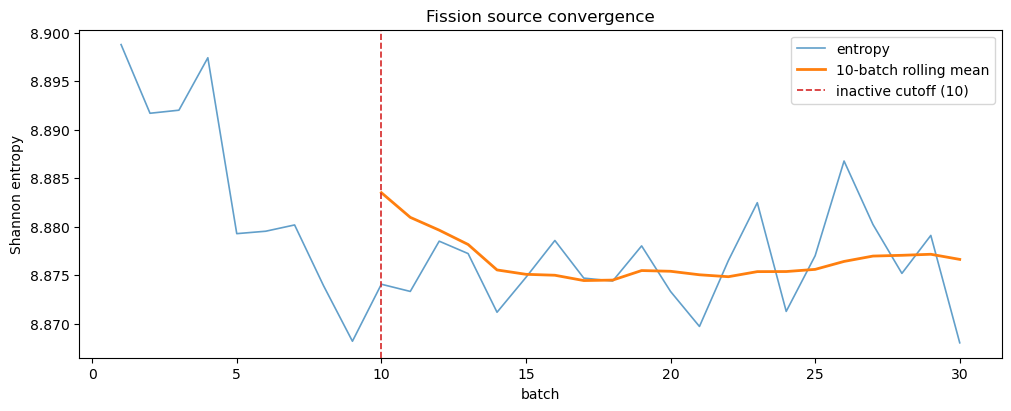

/home/pablo/modelica/ReactorKineticsLab/openmc/ploting.py:325: RuntimeWarning: invalid value encountered in divide
  flux_rel_err = np.ma.masked_where((flux <= 0.0) | ~np.isfinite(flux_std), flux_std / flux)
/home/pablo/modelica/ReactorKineticsLab/openmc/ploting.py:326: RuntimeWarning: invalid value encountered in divide
  fission_rel_err = np.ma.masked_where((fission <= 0.0) | ~np.isfinite(fission_std), fission_std / fission)


global-mesh histories per bin: 9.375
flux nonzero fraction: 0.369
fission nonzero fraction: 0.015
This mesh is strongly under-sampled. Increase active batches and particles, or reduce the mesh size for a readable map.


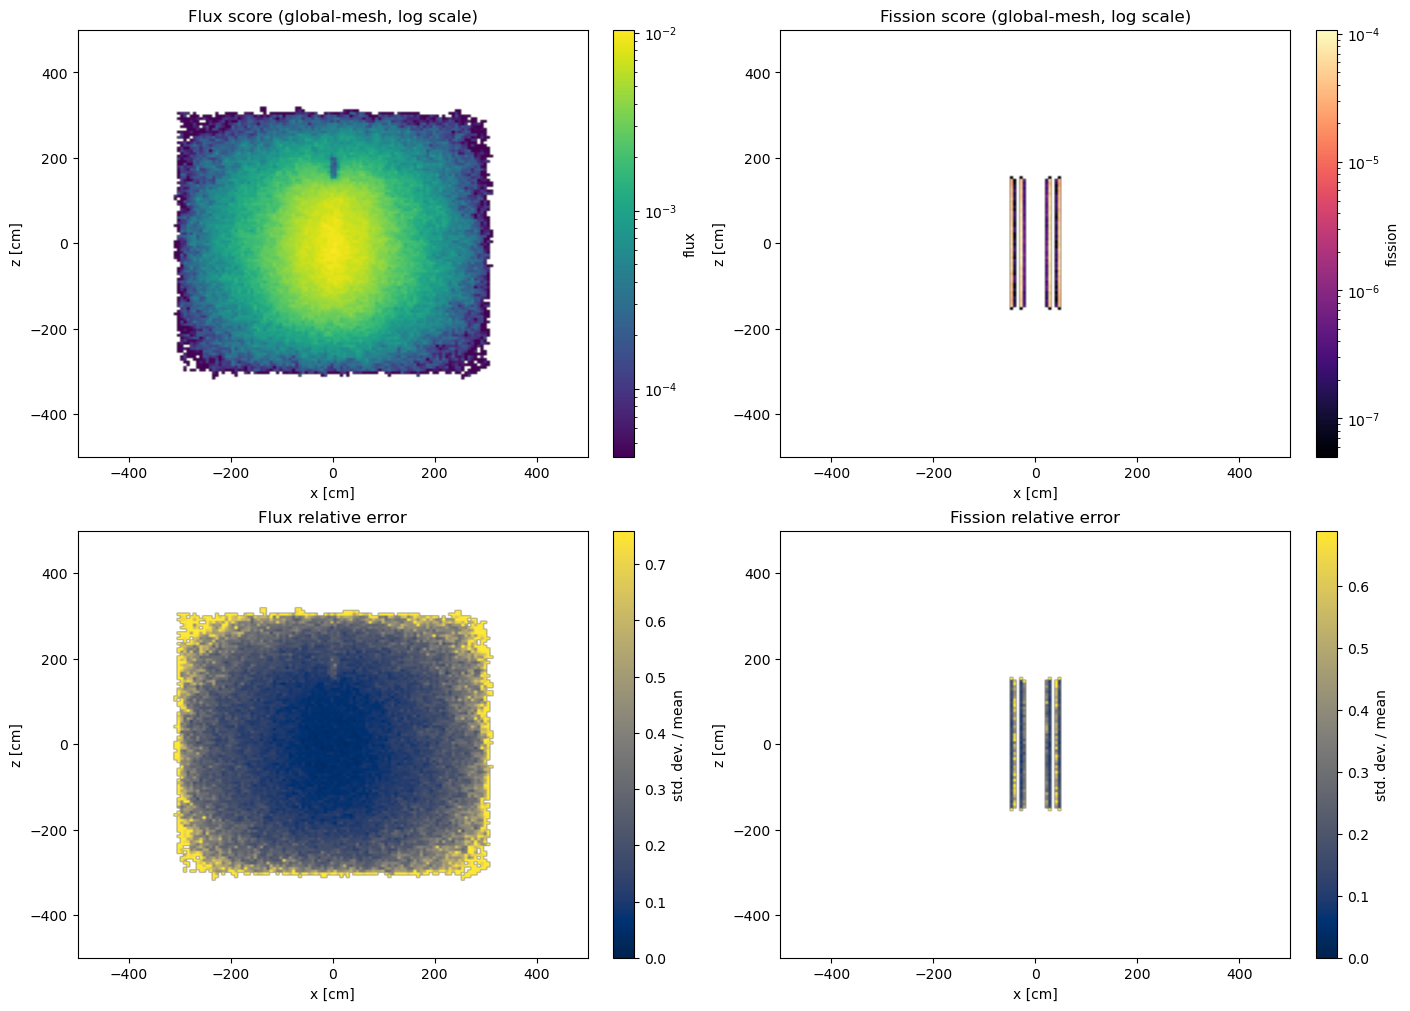

In [4]:
show_statepoint_diagnostics(
    statepoint_path,
    reference_metadata,
    FUEL_ELEMENT_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
)